[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lifeng6666666/freeLearnLab/blob/main/reinforcement-learning/ch04_mc_control.ipynb)


In [ ]:
# Colab 环境准备：安装依赖并获取 viz_utils.py（本地 Jupyter 运行可跳过本格）
import os
if "google.colab" in str(get_ipython()):
    !pip install -q gymnasium
    if not os.path.exists('viz_utils.py'):
        !wget -q https://raw.githubusercontent.com/lifeng6666666/freeLearnLab/main/reinforcement-learning/viz_utils.py


# Ch04 - 蒙特卡洛方法

通过完整回合的经验用样本平均估计价值。在 **Blackjack（21 点）** 上学策略——这是 MC 的“招牌”环境：无模型、回合制、奖励稀疏（只在回合末给 ±1/0）。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。运行前请先执行 `pip install torch gymnasium numpy matplotlib tqdm`。

In [1]:
# 本单元导入本教程通用工具与第三方库
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字体配置（Linux 路径，macOS 用户请改用 Heiti SC 或 PingFang SC）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# PyTorch 设备选择
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch 版本: {torch.__version__}')
print(f'使用设备: {device}')
print(f'Gymnasium 版本: {gym.__version__}')


PyTorch 版本: 2.13.0+cpu
使用设备: cpu
Gymnasium 版本: 1.3.0


## 4.1 蒙特卡洛（MC）方法

MC 的核心思想：用多次完整回合的样本平均估计价值函数。

**特点**：
- 无需 MDP 模型（无模型 RL 入门）
- 必须等回合结束才能更新
- 适合分回合任务（episodic）

**两种变体**：
- **首次访问 MC**：每回合只对状态的第一次出现计算回报
- **每次访问 MC**：对状态的每次出现都计算回报

Blackjack 是 MC 的经典实验环境：状态空间自然分回合，转移概率依赖随机洗牌难以显式计算，DP 几乎不可行，而 MC 只需“打几局、看结果”就能学到接近最优的策略。

## 4.2 Blackjack（21 点）规则

**目标**：手牌总点数尽可能接近 21 但不超过 21，且比庄家更接近 21。

**牌点**：
- 2–10：按面值
- J / Q / K：10 点
- A：1 或 11（取不爆牌的更好值；若 A 计为 11 时仍 ≤21，称为“可用 A / usable ace”）

**玩家行动**：
- **要牌（Hit，动作 1）**：再抽一张
- **停牌（Stick，动作 0）**：结束自己回合

**庄家策略**（固定）：明牌后补一张暗牌；总点数 < 17 时必须要牌，≥ 17 时必须停牌。

**结算**（玩家视角，回合末一次性给奖励，中途均为 0）：
- 玩家爆牌（>21）→ **-1**（输）
- 玩家未爆，庄家爆牌 → **+1**（赢）
- 都未爆：玩家点数 > 庄家 → **+1**；= → **0**（平）；< → **-1**

**状态**：`(player_sum, dealer_show, usable_ace)`
- `player_sum` ∈ [12, 21]（≤11 时下一张必不爆，无需决策）
- `dealer_show` ∈ [1, 10]（庄家明牌点数；A 记为 1）
- `usable_ace` ∈ {0, 1}

> Blackjack 是教科书（Sutton & Barto）第 5 章 MC 的标准示例，正是 MC 的“无模型 + 回合制 + 奖励稀疏”三大特性的最佳展示。

In [2]:
env = gym.make('Blackjack-v1', natural=False, sab=False)
print(f'动作空间: {env.action_space}')        # Discrete(2): 0=Stick, 1=Hit
print(f'观测空间: {env.observation_space}')   # Tuple(Discrete(32), Discrete(11), Discrete(2))

# 跑一回合看流程
s, _ = env.reset(seed=42)
print(f'初始状态 (player_sum, dealer_show, usable_ace): {s}')
trajectory = []
done = False
while not done:
    a = 1 if s[0] < 17 else 0   # 简单基线：点数<17就要牌
    s_next, r, terminated, truncated, _ = env.step(a)
    trajectory.append((s, a, r, s_next))
    s, done = s_next, terminated or truncated
print(f'轨迹: {trajectory}')
print(f'最终奖励: {r}')

动作空间: Discrete(2)
观测空间: Tuple(Discrete(32), Discrete(11), Discrete(2))
初始状态 (player_sum, dealer_show, usable_ace): (15, 2, 0)
轨迹: [((15, 2, 0), 1, -1.0, (25, 2, 0))]
最终奖励: -1.0


## 4.3 ε-greedy 探索

MC 控制必须解决探索问题：
- **ε-greedy**：以 $1-\epsilon$ 概率选贪心动作，以 $\epsilon$ 概率随机选
- **ε 衰减**：训练前期高 ε 多探索，后期低 ε 多利用

Blackjack 的奖励只在回合末给（±1 或 0），中途全为 0。若 Q 初始化为 0 且不探索，agent 会以为所有动作一样而无法学习——必须靠 ε-greedy 强制探索 + 大量回合采样，才能正确估计每个 (state, action) 的期望回报。

## 4.4 MC 控制算法

完整的 on-policy MC 控制流程（首次访问版本）：

1. 用 ε-greedy 生成一回合轨迹
2. 从后向前累折扣回报 $G_t$
3. 对每个 (s, a) 的首次出现，用样本平均更新 $Q(s,a)$
4. ε 随训练衰减

Blackjack 中 $\gamma=1$（回合短、无时序偏好），且状态几乎不重复，首次访问与每次访问等价。

In [3]:
from collections import defaultdict

def epsilon_greedy(Q, state, nA, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(nA)
    return int(Q[state].argmax())

def mc_control(env, episodes=100_000, gamma=1.0, eps_start=1.0, eps_end=0.05):
    nA = env.action_space.n
    Q = defaultdict(lambda: np.zeros(nA))
    N = defaultdict(lambda: np.zeros(nA))
    for ep in range(episodes):
        epsilon = max(eps_end, eps_start - ep / (episodes * 0.8))
        # 1. 生成一回合
        s, _ = env.reset()
        trajectory = []
        done = False
        while not done:
            a = epsilon_greedy(Q, s, nA, epsilon)
            s_next, r, terminated, truncated, _ = env.step(a)
            trajectory.append((s, a, r))
            s, done = s_next, terminated or truncated

        # 2. 首次访问 MC 更新
        G = 0
        visited = set()
        for s, a, r in reversed(trajectory):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                N[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / N[s][a]
        if (ep + 1) % 20_000 == 0:
            print(f'  episode {ep+1}/{episodes} | ε={epsilon:.3f} | 已观测状态数={len(Q)}')

    return Q

print('训练 Monte Carlo 控制...')
Q = mc_control(env, episodes=100_000)
print('训练完成 ✓')

训练 Monte Carlo 控制...
  episode 20000/100000 | ε=0.750 | 已观测状态数=280
  episode 40000/100000 | ε=0.500 | 已观测状态数=280
  episode 60000/100000 | ε=0.250 | 已观测状态数=280
  episode 80000/100000 | ε=0.050 | 已观测状态数=280
  episode 100000/100000 | ε=0.050 | 已观测状态数=280
训练完成 ✓


## 4.5 评估学到的策略

跑 100,000 回合统计胜/平/负率。Blackjack 即使最优策略也赢不过庄家（庄家有“先看玩家爆牌”的优势），期望回报约 -5%。

In [4]:
def evaluate(env, Q, episodes=100_000):
    win, draw, lose = 0, 0, 0
    for _ in range(episodes):
        s, _ = env.reset()
        done = False
        while not done:
            a = int(Q[s].argmax())
            s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
        if r > 0: win += 1
        elif r < 0: lose += 1
        else: draw += 1
    total = win + draw + lose
    print(f'胜: {win/total:.2%} | 平: {draw/total:.2%} | 负: {lose/total:.2%}')
    print(f'平均回报: {(win - lose) / total:+.4f}')

evaluate(env, Q, episodes=100_000)

胜: 42.32% | 平: 7.71% | 负: 49.98%
平均回报: -0.0766


## 4.6 可视化学到的策略与价值

- **策略热力图**：玩家点数 × 庄家明牌，蓝=停牌，红=要牌
- **状态价值热力图**：$V(s) = \max_a Q(s,a)$，颜色越绿价值越高

对比 Sutton & Barto 教材的最优策略：玩家点数 ≥ 20 一律停牌；点数 ≤ 11 一律要牌；12–19 视庄家明牌而定。

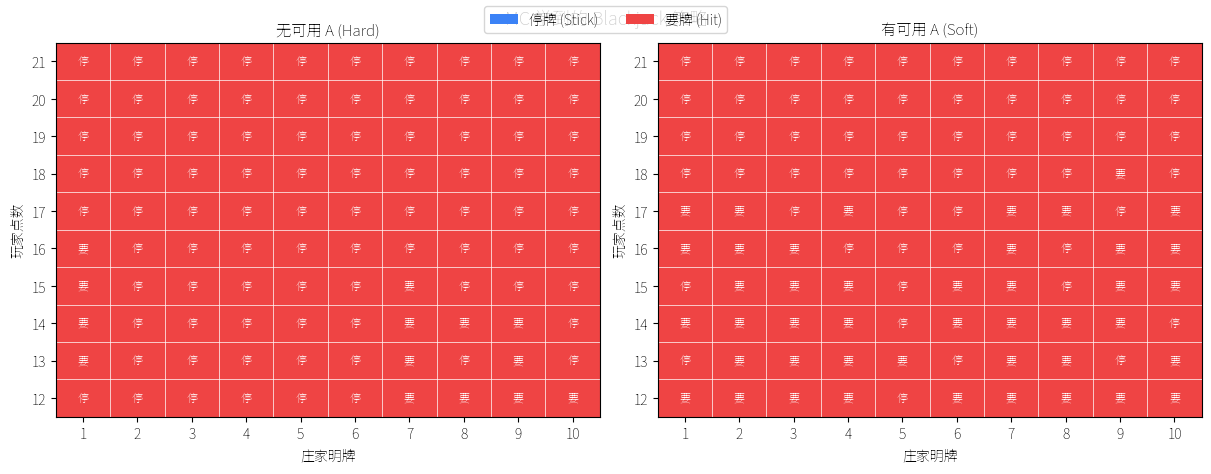

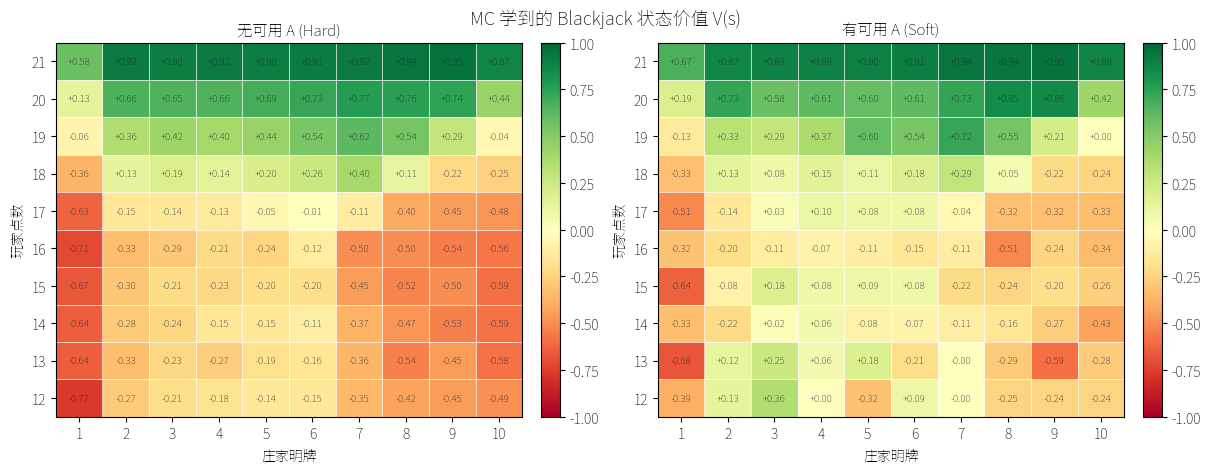

In [5]:
from viz_utils import visualize_blackjack_policy, visualize_blackjack_value

visualize_blackjack_policy(Q, title='MC 学到的 Blackjack 策略')
visualize_blackjack_value(Q, title='MC 学到的 Blackjack 状态价值 V(s)')

## 4.7 小结

- **MC vs DP**：DP 已知 MDP 直接计算；MC 不知道 MDP，通过采样学习
- **Blackjack 是 MC 的“招牌”**：转移概率难显式计算，DP 不可行，而 MC 几十万局就能学到接近最优的策略
- **MC 优点**：直观、无偏、无需 MDP
- **MC 缺点**：必须等回合结束、方差大、不适用于连续任务

下一章的 **时序差分（TD）** 方法将解决这些问题——结合 DP 的单步更新与 MC 的无模型特性。